# Part

## 1.Importing the technologies

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.signal import find_peaks

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

## 2. Loading the video and model paths

In [8]:
def load_paths():

    video_path = "Bily_1.mp4"
    brady_path = "Bily_2.mp4"
    model_path = "hand_landmarker.task"

    print("Video path:", video_path)
    print("Brady path:", brady_path)
    print("Model path:", model_path)

    return video_path, brady_path, model_path

In [9]:
video_path, brady_path, model_path = load_paths()

Video path: Bily_1.mp4
Brady path: Bily_2.mp4
Model path: hand_landmarker.task


In [10]:
def get_video_info(video_path, label):

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: could not open {label} video.")
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duration = total_frames / fps

    print("####################################################")
    print(f"{label} VIDEO")
    print("####################################################")

    print("FPS:", fps)
    print("Total frames:", total_frames)
    print("Duration:", duration, "seconds")

    cap.release()

    return fps, total_frames, duration

In [11]:
normal_info = get_video_info(video_path, "NORMAL")

brady_info = get_video_info(brady_path, "BRADYKINESIA")

####################################################
NORMAL VIDEO
####################################################
FPS: 29.94736842105263
Total frames: 569.0
Duration: 19.0 seconds
####################################################
BRADYKINESIA VIDEO
####################################################
FPS: 29.94736842105263
Total frames: 569.0
Duration: 19.0 seconds


## 3. Loading the MediaPipe Hand Landmarker

In [12]:
base_options = python.BaseOptions(model_asset_path=model_path)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

detector = vision.HandLandmarker.create_from_options(options)

print("MediaPipe Hand Landmarker loaded successfully.")

MediaPipe Hand Landmarker loaded successfully.


I0000 00:00:1778424560.876839   21823 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1778424560.879890   21846 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: Mesa Intel(R) Graphics (RPL-S)
W0000 00:00:1778424560.911138   21825 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778424560.928290   21841 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 4. Reading the video frame by frame

In [13]:
def read_video_frames(video_path, label):

    cap = cv2.VideoCapture(video_path)

    frame_count = 0

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        frame_count += 1

        print(f"{label} - Reading frame:", frame_count)

    cap.release()

    print(f"{label} video reading completed.")

    return frame_count

In [14]:
normal_frames = read_video_frames(video_path, "NORMAL")

brady_frames = read_video_frames(brady_path, "BRADYKINESIA")

NORMAL - Reading frame: 1
NORMAL - Reading frame: 2
NORMAL - Reading frame: 3
NORMAL - Reading frame: 4
NORMAL - Reading frame: 5
NORMAL - Reading frame: 6
NORMAL - Reading frame: 7
NORMAL - Reading frame: 8
NORMAL - Reading frame: 9
NORMAL - Reading frame: 10
NORMAL - Reading frame: 11
NORMAL - Reading frame: 12
NORMAL - Reading frame: 13
NORMAL - Reading frame: 14
NORMAL - Reading frame: 15
NORMAL - Reading frame: 16
NORMAL - Reading frame: 17
NORMAL - Reading frame: 18
NORMAL - Reading frame: 19
NORMAL - Reading frame: 20
NORMAL - Reading frame: 21
NORMAL - Reading frame: 22
NORMAL - Reading frame: 23
NORMAL - Reading frame: 24
NORMAL - Reading frame: 25
NORMAL - Reading frame: 26
NORMAL - Reading frame: 27
NORMAL - Reading frame: 28
NORMAL - Reading frame: 29
NORMAL - Reading frame: 30
NORMAL - Reading frame: 31
NORMAL - Reading frame: 32
NORMAL - Reading frame: 33
NORMAL - Reading frame: 34
NORMAL - Reading frame: 35
NORMAL - Reading frame: 36
NORMAL - Reading frame: 37
NORMAL - R

## 5. Displaying the video

In [15]:
def display_video(video_path, label):

    cap = cv2.VideoCapture(video_path)

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        cv2.imshow(f"{label} Video", frame)

        # Press q to quit
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

    print(f"{label} video display completed.")

In [16]:
display_video(video_path, "NORMAL")

display_video(brady_path, "BRADYKINESIA")

NORMAL video display completed.
BRADYKINESIA video display completed.


## 6. Detecting hand landmarks

In [17]:
def detect_hand_landmarks(video_path, label, detector):

    cap = cv2.VideoCapture(video_path)

    frame_count = 0
    detected_frames = 0

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        frame_count += 1

        # Convert BGR to RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Convert to MediaPipe image
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb_frame
        )

        # Detect hands
        detection_result = detector.detect(mp_image)

        # Check if a hand exists
        if detection_result.hand_landmarks:

            detected_frames += 1

            print(f"{label} - Hand detected in frame {frame_count}")

    cap.release()

    print("======================================")
    print(f"{label} Landmark Detection Completed")
    print("======================================")
    print("Total frames:", frame_count)
    print("Frames with detected hands:", detected_frames)

    return detected_frames

In [18]:
normal_detected = detect_hand_landmarks(
    video_path,
    "NORMAL",
    detector
)

brady_detected = detect_hand_landmarks(
    brady_path,
    "BRADYKINESIA",
    detector
)

W0000 00:00:1778424714.744833   21843 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


NORMAL - Hand detected in frame 1
NORMAL - Hand detected in frame 2
NORMAL - Hand detected in frame 3
NORMAL - Hand detected in frame 4
NORMAL - Hand detected in frame 5
NORMAL - Hand detected in frame 6
NORMAL - Hand detected in frame 7
NORMAL - Hand detected in frame 8
NORMAL - Hand detected in frame 9
NORMAL - Hand detected in frame 10
NORMAL - Hand detected in frame 11
NORMAL - Hand detected in frame 12
NORMAL - Hand detected in frame 13
NORMAL - Hand detected in frame 14
NORMAL - Hand detected in frame 15
NORMAL - Hand detected in frame 16
NORMAL - Hand detected in frame 17
NORMAL - Hand detected in frame 18
NORMAL - Hand detected in frame 19
NORMAL - Hand detected in frame 20
NORMAL - Hand detected in frame 21
NORMAL - Hand detected in frame 22
NORMAL - Hand detected in frame 23
NORMAL - Hand detected in frame 24
NORMAL - Hand detected in frame 25
NORMAL - Hand detected in frame 26
NORMAL - Hand detected in frame 27
NORMAL - Hand detected in frame 28
NORMAL - Hand detected in fra

## 7. Computing the distance signal between thumb and index finger

In [19]:
def extract_distance_signal(video_path, label, detector):

    cap = cv2.VideoCapture(video_path)

    distances = []
    frames = []

    frame_count = 0

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        frame_count += 1

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb_frame
        )

        detection_result = detector.detect(mp_image)

        if detection_result.hand_landmarks:

            hand_landmarks = detection_result.hand_landmarks[0]

            # Thumb tip
            thumb_tip = hand_landmarks[4]

            # Index tip
            index_tip = hand_landmarks[8]

            # Coordinates
            x1, y1 = thumb_tip.x, thumb_tip.y
            x2, y2 = index_tip.x, index_tip.y

            # Euclidean distance
            distance = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

            distances.append(distance)
            frames.append(frame_count)

    cap.release()

    print("======================================")
    print(f"{label} Distance Signal Extracted")
    print("======================================")
    print("Number of points:", len(distances))

    return np.array(distances), frames

In [20]:
normal_signal, normal_frames = extract_distance_signal(
    video_path,
    "NORMAL",
    detector
)

brady_signal, brady_frames = extract_distance_signal(
    brady_path,
    "BRADYKINESIA",
    detector
)

NORMAL Distance Signal Extracted
Number of points: 569
BRADYKINESIA Distance Signal Extracted
Number of points: 569


## 8. Plotting the distance signal

In [21]:
def plot_distance_signal(frames, signal, label):

    plt.figure(figsize=(12, 5))

    plt.plot(frames, signal)

    plt.title(f"{label} - Distance Signal Between Thumb and Index Finger")
    plt.xlabel("Frame")
    plt.ylabel("Distance")

    plt.grid(True)
    plt.show()

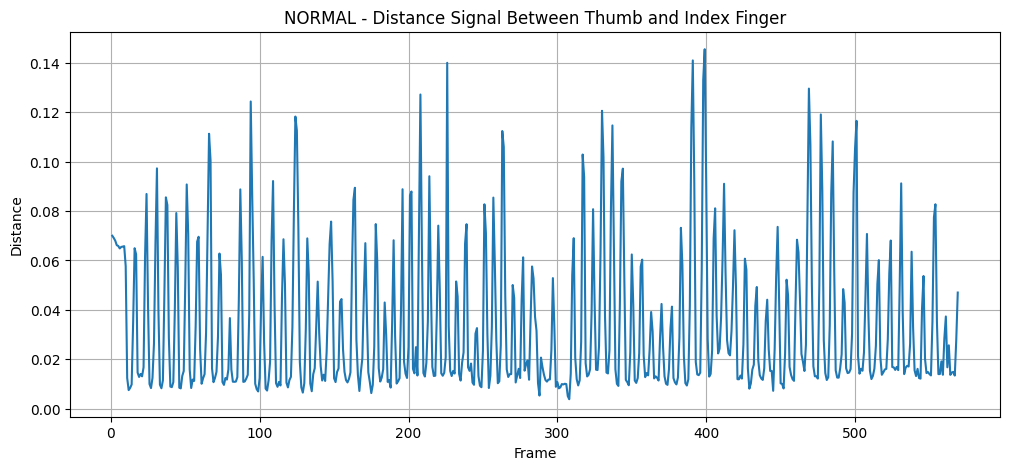

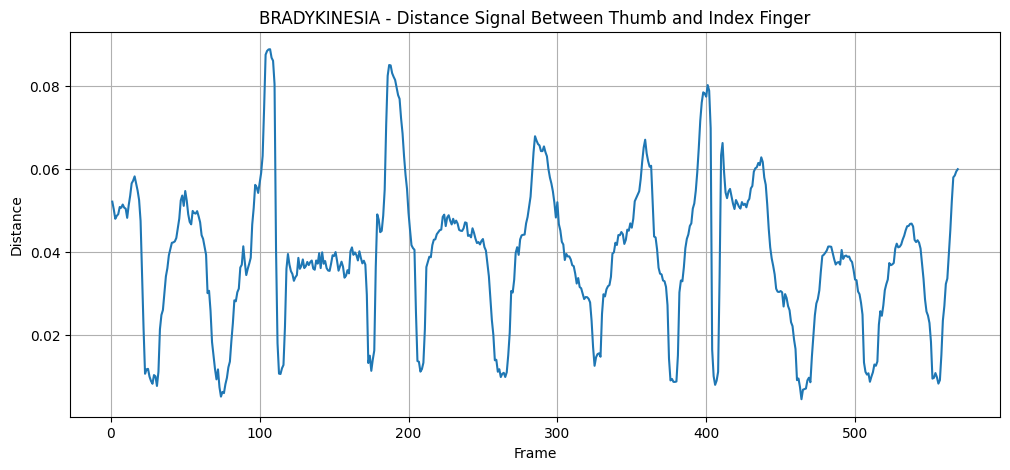

In [22]:
plot_distance_signal(
    normal_frames,
    normal_signal,
    "NORMAL"
)

plot_distance_signal(
    brady_frames,
    brady_signal,
    "BRADYKINESIA"
)

## 9. Detecting finger taps

In [23]:
def detect_finger_taps(signal, label, distance=5, prominence=0.005):

    # Convert to numpy array
    signal = np.array(signal)

    # Invert signal to detect minima
    inverted_signal = -signal

    # Detect peaks
    peaks, _ = find_peaks(
        inverted_signal,
        distance=distance,
        prominence=prominence
    )

    print("======================================")
    print(f"{label} Finger Tap Detection")
    print("======================================")
    print("Number of taps detected:", len(peaks))

    return peaks

In [24]:
normal_peaks = detect_finger_taps(
    normal_signal,
    "NORMAL"
)

brady_peaks = detect_finger_taps(
    brady_signal,
    "BRADYKINESIA"
)

NORMAL Finger Tap Detection
Number of taps detected: 77
BRADYKINESIA Finger Tap Detection
Number of taps detected: 16


## 10. Visualizing hand landmarks on the video

In [25]:
def visualize_hand_landmarks(video_path, label, detector):

    cap = cv2.VideoCapture(video_path)

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        # Convert BGR → RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # MediaPipe image
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb_frame
        )

        # Detect hand
        detection_result = detector.detect(mp_image)

        if detection_result.hand_landmarks:

            hand_landmarks = detection_result.hand_landmarks[0]

            # Thumb tip
            thumb_tip = hand_landmarks[4]

            # Index tip
            index_tip = hand_landmarks[8]

            h, w, _ = frame.shape

            # Convert normalized coordinates to pixels
            thumb_x = int(thumb_tip.x * w)
            thumb_y = int(thumb_tip.y * h)

            index_x = int(index_tip.x * w)
            index_y = int(index_tip.y * h)

            # Draw circles
            cv2.circle(frame, (thumb_x, thumb_y), 10, (0,255,0), -1)
            cv2.circle(frame, (index_x, index_y), 10, (0,0,255), -1)

            # Draw line
            cv2.line(
                frame,
                (thumb_x, thumb_y),
                (index_x, index_y),
                (255,0,0),
                3
            )

        # Show frame
        cv2.imshow(f"{label} Finger Tapping Analysis", frame)

        # Press q to quit
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

    print(f"{label} landmark visualization completed.")

In [26]:
visualize_hand_landmarks(
    video_path,
    "NORMAL",
    detector
)

visualize_hand_landmarks(
    brady_path,
    "BRADYKINESIA",
    detector
)

NORMAL landmark visualization completed.
BRADYKINESIA landmark visualization completed.


## 11. Visualizing detected finger taps

In [27]:
def visualize_detected_taps(signal, peaks, label):

    plt.figure(figsize=(14,5))

    # Original signal
    plt.plot(signal, label="Distance Signal")

    # Detected taps
    plt.plot(
        peaks,
        signal[peaks],
        "ro",
        label="Detected Taps"
    )

    plt.title(f"{label} - Finger Tap Detection")
    plt.xlabel("Frame")
    plt.ylabel("Distance")

    plt.legend()
    plt.grid(True)

    plt.show()

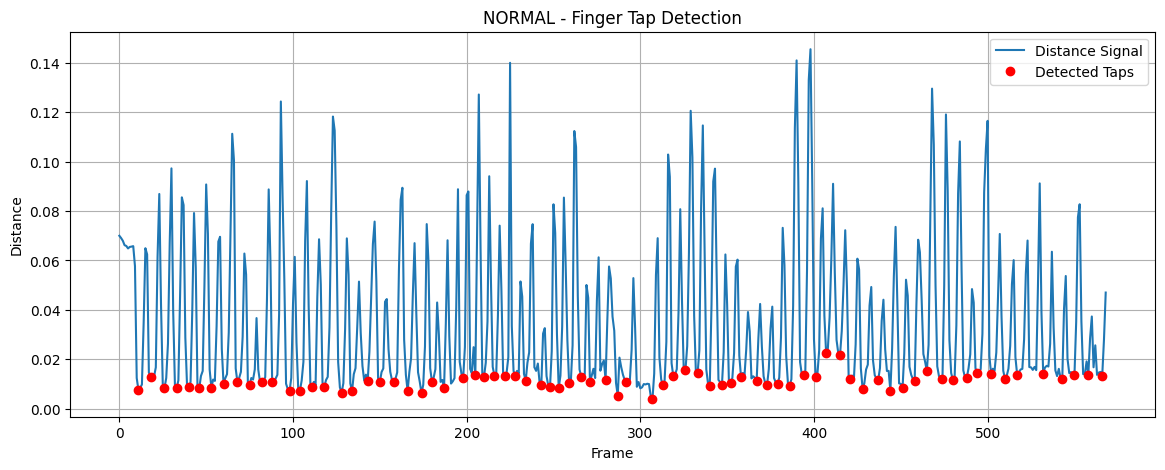

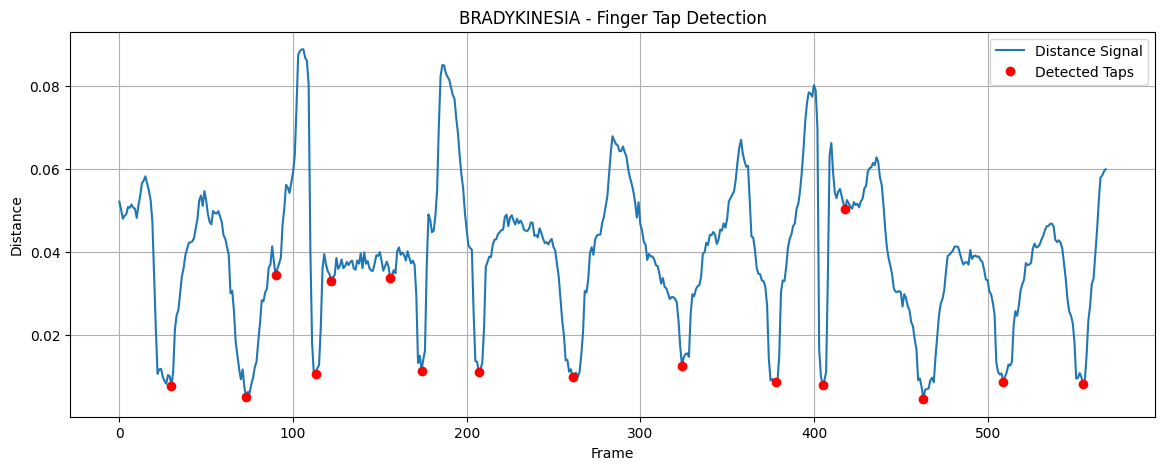

In [28]:
visualize_detected_taps(
    normal_signal,
    normal_peaks,
    "NORMAL"
)

visualize_detected_taps(
    brady_signal,
    brady_peaks,
    "BRADYKINESIA"
)

## 12. Extracting biomedical motion features

In [29]:
def extract_finger_tapping_features(signal, peaks, duration, label):

    # Video duration
    duration_seconds = duration

    # Number of taps
    num_taps = len(peaks)

    # Tapping speed
    speed = num_taps / duration_seconds

    # Signal amplitude
    amplitude = np.max(signal) - np.min(signal)

    # Time intervals between taps
    intervals = np.diff(peaks)

    # Variability
    variability = np.std(intervals)

    # Mean interval
    mean_interval = np.mean(intervals)

    print("======================================")
    print(f"{label} Finger Tapping Features")
    print("======================================")

    print("Video duration:", duration_seconds, "seconds")
    print("Number of taps:", num_taps)
    print("Tapping speed:", speed, "taps/sec")
    print("Amplitude:", amplitude)
    print("Mean interval:", mean_interval)
    print("Variability:", variability)

    return {
        "duration": duration_seconds,
        "num_taps": num_taps,
        "speed": speed,
        "amplitude": amplitude,
        "mean_interval": mean_interval,
        "variability": variability
    }

In [30]:
normal_features = extract_finger_tapping_features(
    normal_signal,
    normal_peaks,
    normal_info[2],
    "NORMAL"
)

brady_features = extract_finger_tapping_features(
    brady_signal,
    brady_peaks,
    brady_info[2],
    "BRADYKINESIA"
)

NORMAL Finger Tapping Features
Video duration: 19.0 seconds
Number of taps: 77
Tapping speed: 4.052631578947368 taps/sec
Amplitude: 0.14157675839249872
Mean interval: 7.302631578947368
Variability: 1.813833805725388
BRADYKINESIA Finger Tapping Features
Video duration: 19.0 seconds
Number of taps: 16
Tapping speed: 0.8421052631578947 taps/sec
Amplitude: 0.08430690807857347
Mean interval: 35.0
Variability: 16.1203804752452


## 13. Saving the processed tracking video

In [31]:
def save_processed_tracking_video(video_path, label, detector, peaks, frames, output_video_name):

    cap = cv2.VideoCapture(video_path)

    # Video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Output video
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    out = cv2.VideoWriter(
        output_video_name,
        fourcc,
        fps,
        (width, height)
    )

    tap_counter = 0
    peak_index = 0

    frame_count = 0

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        frame_count += 1

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb_frame
        )

        detection_result = detector.detect(mp_image)

        if detection_result.hand_landmarks:

            hand_landmarks = detection_result.hand_landmarks[0]

            thumb_tip = hand_landmarks[4]
            index_tip = hand_landmarks[8]

            h, w, _ = frame.shape

            thumb_x = int(thumb_tip.x * w)
            thumb_y = int(thumb_tip.y * h)

            index_x = int(index_tip.x * w)
            index_y = int(index_tip.y * h)

            # Draw circles
            cv2.circle(frame, (thumb_x, thumb_y), 10, (0,255,0), -1)
            cv2.circle(frame, (index_x, index_y), 10, (0,0,255), -1)

            # Draw line
            cv2.line(
                frame,
                (thumb_x, thumb_y),
                (index_x, index_y),
                (255,0,0),
                3
            )

        # Count taps
        if peak_index < len(peaks):

            real_frame_number = frames[peaks[peak_index]]

            if frame_count == real_frame_number:

                tap_counter += 1
                peak_index += 1

        # Display condition + tap counter
        cv2.putText(
            frame,
            f"{label} | Taps: {tap_counter}",
            (30,50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0,255,255),
            3
        )

        # Write frame
        out.write(frame)

    cap.release()
    out.release()

    print(f"{label} processed video saved as {output_video_name}")

In [32]:
save_processed_tracking_video(
    video_path,
    "NORMAL",
    detector,
    normal_peaks,
    normal_frames,
    "normal_tracked_output.mp4"
)

save_processed_tracking_video(
    brady_path,
    "BRADYKINESIA",
    detector,
    brady_peaks,
    brady_frames,
    "bradykinesia_tracked_output.mp4"
)

NORMAL processed video saved as normal_tracked_output.mp4
BRADYKINESIA processed video saved as bradykinesia_tracked_output.mp4


# 14. Comparaison

In [33]:
comparison = pd.DataFrame({
    "Feature": [
        "Duration (seconds)",
        "Number of taps",
        "Tapping speed (taps/sec)",
        "Amplitude",
        "Mean interval",
        "Variability"
    ],

    "Normal": [
        normal_features["duration"],
        normal_features["num_taps"],
        normal_features["speed"],
        normal_features["amplitude"],
        normal_features["mean_interval"],
        normal_features["variability"]
    ],

    "Simulated Bradykinesia": [
        brady_features["duration"],
        brady_features["num_taps"],
        brady_features["speed"],
        brady_features["amplitude"],
        brady_features["mean_interval"],
        brady_features["variability"]
    ]
})

comparison

,Feature,Normal,Simulated Bradykinesia
0,Duration (seconds),19.000000,19.000000
1,Number of taps,77.000000,16.000000
2,Tapping speed (taps/sec),4.052632,0.842105
3,Amplitude,0.141577,0.084307
4,Mean interval,7.302632,35.000000
5,Variability,1.813834,16.120380


In [34]:
comparison.to_csv("normal_vs_bradykinesia_comparison.csv", index=False)

print("CSV saved as normal_vs_bradykinesia_comparison.csv")

CSV saved as normal_vs_bradykinesia_comparison.csv


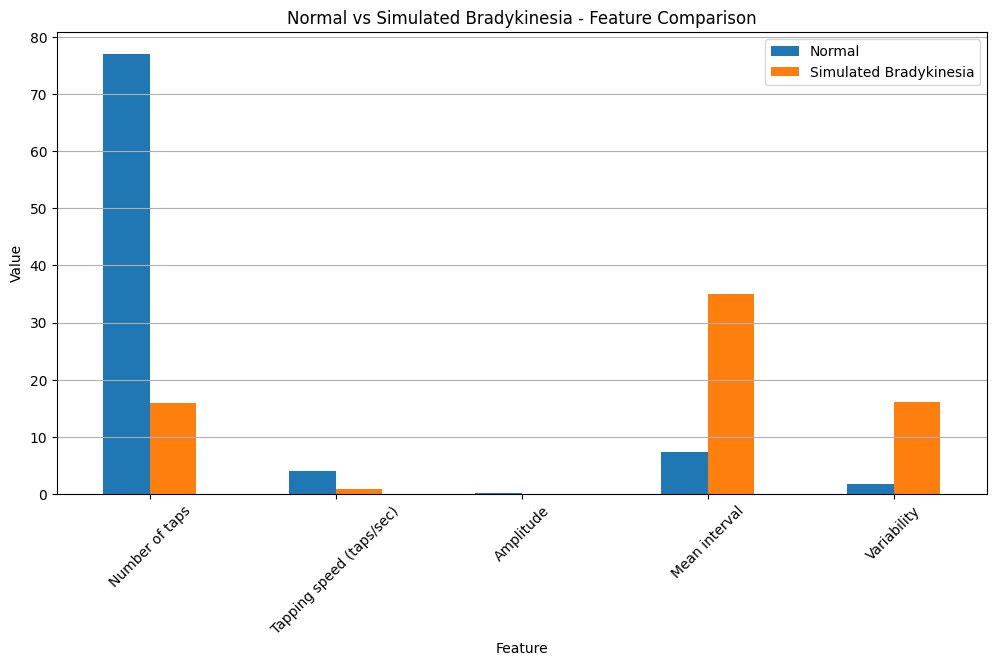

In [35]:
features_to_plot = [
    "Number of taps",
    "Tapping speed (taps/sec)",
    "Amplitude",
    "Mean interval",
    "Variability"
]

plot_df = comparison[comparison["Feature"].isin(features_to_plot)]

plot_df.set_index("Feature")[["Normal", "Simulated Bradykinesia"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Normal vs Simulated Bradykinesia - Feature Comparison")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

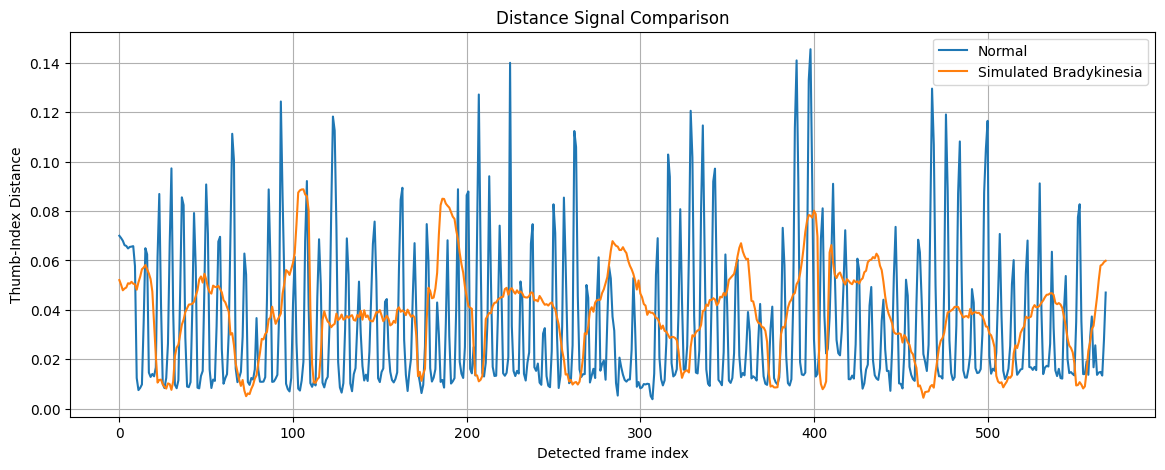

In [36]:
plt.figure(figsize=(14, 5))

plt.plot(normal_signal, label="Normal")
plt.plot(brady_signal, label="Simulated Bradykinesia")

plt.title("Distance Signal Comparison")
plt.xlabel("Detected frame index")
plt.ylabel("Thumb-Index Distance")
plt.legend()
plt.grid(True)
plt.show()

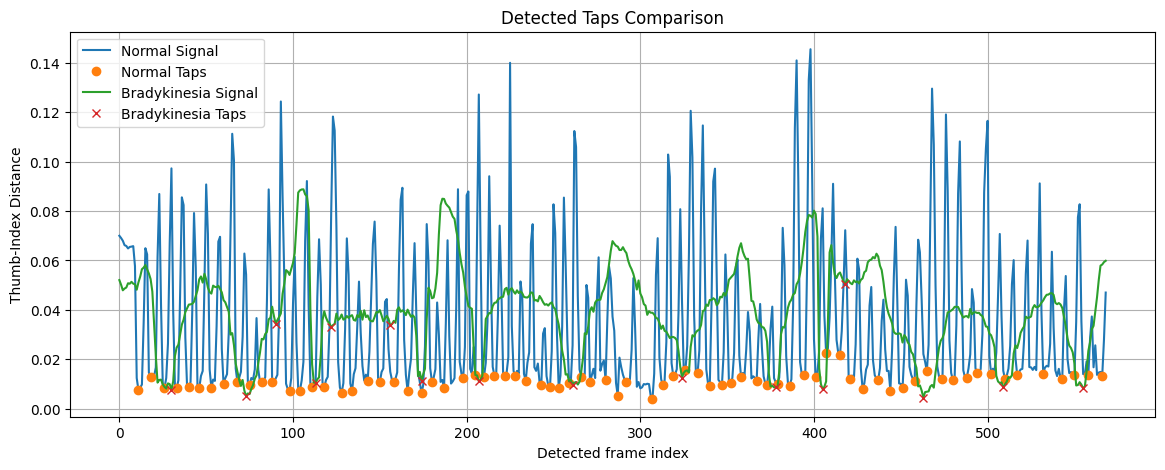

In [37]:
plt.figure(figsize=(14, 5))

plt.plot(normal_signal, label="Normal Signal")
plt.plot(normal_peaks, normal_signal[normal_peaks], "o", label="Normal Taps")

plt.plot(brady_signal, label="Bradykinesia Signal")
plt.plot(brady_peaks, brady_signal[brady_peaks], "x", label="Bradykinesia Taps")

plt.title("Detected Taps Comparison")
plt.xlabel("Detected frame index")
plt.ylabel("Thumb-Index Distance")
plt.legend()
plt.grid(True)
plt.show()

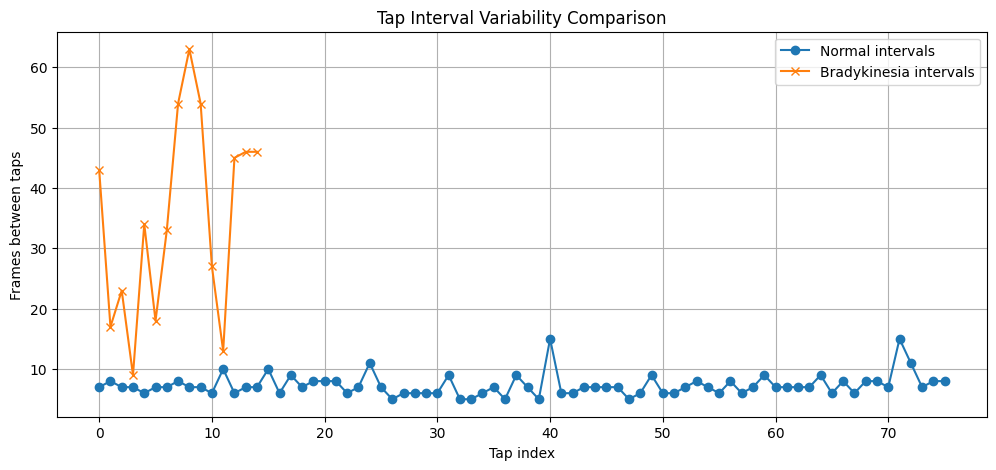

In [38]:
normal_intervals = np.diff(normal_peaks)
brady_intervals = np.diff(brady_peaks)

plt.figure(figsize=(12, 5))

plt.plot(normal_intervals, marker="o", label="Normal intervals")
plt.plot(brady_intervals, marker="x", label="Bradykinesia intervals")

plt.title("Tap Interval Variability Comparison")
plt.xlabel("Tap index")
plt.ylabel("Frames between taps")
plt.legend()
plt.grid(True)
plt.show()

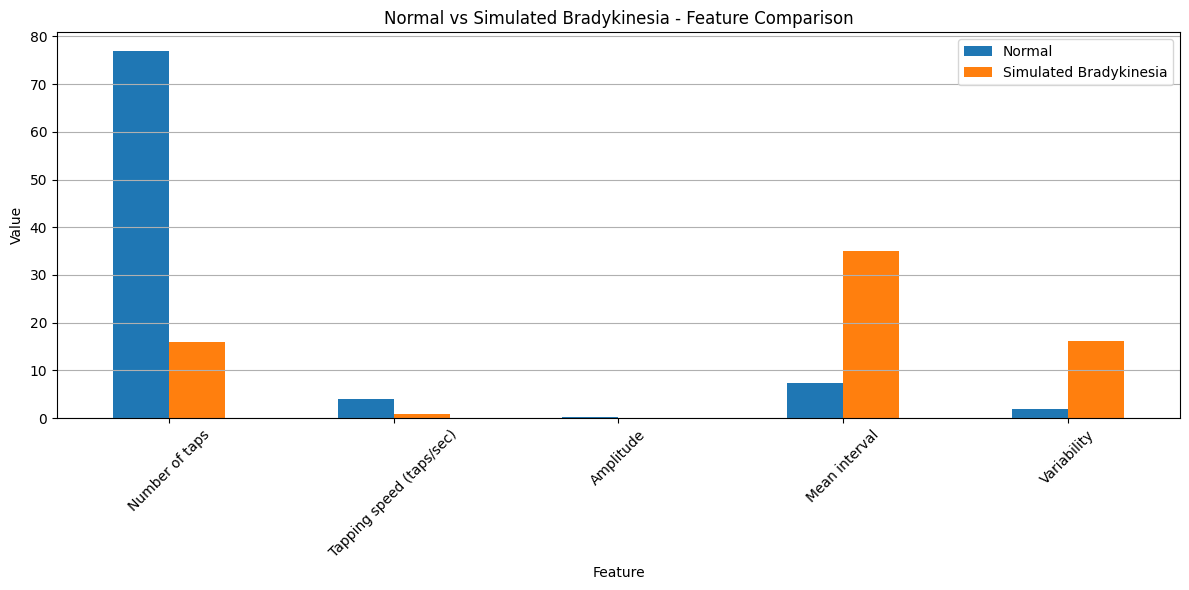

Saved: feature_comparison.png


In [39]:
# Save comparison table plot
plot_df.set_index("Feature")[["Normal", "Simulated Bradykinesia"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Normal vs Simulated Bradykinesia - Feature Comparison")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("feature_comparison.png", dpi=300)
plt.show()

print("Saved: feature_comparison.png")